# Suspicious Web Activity Exploration

This project explores the "Suspicious Web Threat Interactions (VPC Flow Data: Network Traffic from Malicious IPs)" [dataset](https://www.kaggle.com/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions) available on Kaggle.

## Understanding the data


(copied from Kaggle description of dataset)

Each entry in the dataset represents a stream of traffic to a web server, including the following columns:

* bytes_in: Bytes received by the server.

* bytes_out: Bytes sent from the server.

* creation_time: Timestamp of when the record was created.

* end_time: Timestamp of when the connection ended.

* src_ip: Source IP address.

* src_ip_country_code: Country code of the source IP.

* protocol: Protocol used in the connection.

* response.code: HTTP response code.

* dst_port: Destination port on the server.

* dst_ip: Destination IP address.

* rule_names: Name of the rule that identified the traffic as suspicious.

* observation_name: Observations associated with the traffic.

* source.meta: Metadata related to the source.

* source.name: Name of the traffic source.

* time: Timestamp of the detected event.

* detection_types: Type of detection applied.

## Setting up


In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

In [2]:
# https://www.kaggle.com/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions
path = kagglehub.dataset_download("jancsg/cybersecurity-suspicious-web-threat-interactions")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions/versions/1


In [3]:
df = pd.read_csv(path + "/CloudWatch_Traffic_Web_Attack.csv")
print(df.head())
print(df.info())

   bytes_in  bytes_out         creation_time              end_time  \
0      5602      12990  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
1     30912      18186  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
2     28506      13468  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
3     30546      14278  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   
4      6526      13892  2024-04-25T23:00:00Z  2024-04-25T23:10:00Z   

            src_ip src_ip_country_code protocol  response.code  dst_port  \
0   147.161.161.82                  AE    HTTPS            200       443   
1     165.225.33.6                  US    HTTPS            200       443   
2  165.225.212.255                  CA    HTTPS            200       443   
3   136.226.64.114                  US    HTTPS            200       443   
4   165.225.240.79                  NL    HTTPS            200       443   

         dst_ip              rule_names                      observation_name  \
0  10.138.69.97  Suspicious Web Traffic  

In [4]:
unique_values = {
    'protocol': df['protocol'].unique(),
    'rule_names': df['rule_names'].unique(),
    'observation_name': df['observation_name'].unique(),
    'dst_port': df['dst_port'].unique(),
    'detection_types': df['detection_types'].unique(),
    'source.meta': df['source.meta'].unique(),
    'source.name': df['source.name'].unique()
}

for column, values in unique_values.items():
    print(f"\nUnique values in {column}:")
    print(values)


Unique values in protocol:
['HTTPS']

Unique values in rule_names:
['Suspicious Web Traffic']

Unique values in observation_name:
['Adversary Infrastructure Interaction']

Unique values in dst_port:
[443]

Unique values in detection_types:
['waf_rule']

Unique values in source.meta:
['AWS_VPC_Flow']

Unique values in source.name:
['prod_webserver']


In [5]:
print(df.isnull().sum())
# YAY NO NULLS

bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response.code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source.meta            0
source.name            0
time                   0
detection_types        0
dtype: int64


In [6]:
# Convert timestamp columns to datetime type
df ['creation_time'] = pd.to_datetime(df['creation_time'])
df ['end_time'] = pd.to_datetime(df['end_time'])
df ['time'] = pd.to_datetime(df['time'])

In [7]:
# Checking time range
creation_time_range = (df['creation_time'].min(), df['creation_time'].max())
end_time_range = (df['end_time'].min(), df['end_time'].max())

print("Creation Time Range:")
print(f"From: {creation_time_range[0]}")
print(f"To: {creation_time_range[1]}")
print("\nEnd Time Range:")
print(f"From: {end_time_range[0]}")
print(f"To: {end_time_range[1]}")


Creation Time Range:
From: 2024-04-25 23:00:00+00:00
To: 2024-04-26 09:50:00+00:00

End Time Range:
From: 2024-04-25 23:10:00+00:00
To: 2024-04-26 10:00:00+00:00




---


## 1. Bytes Transferred

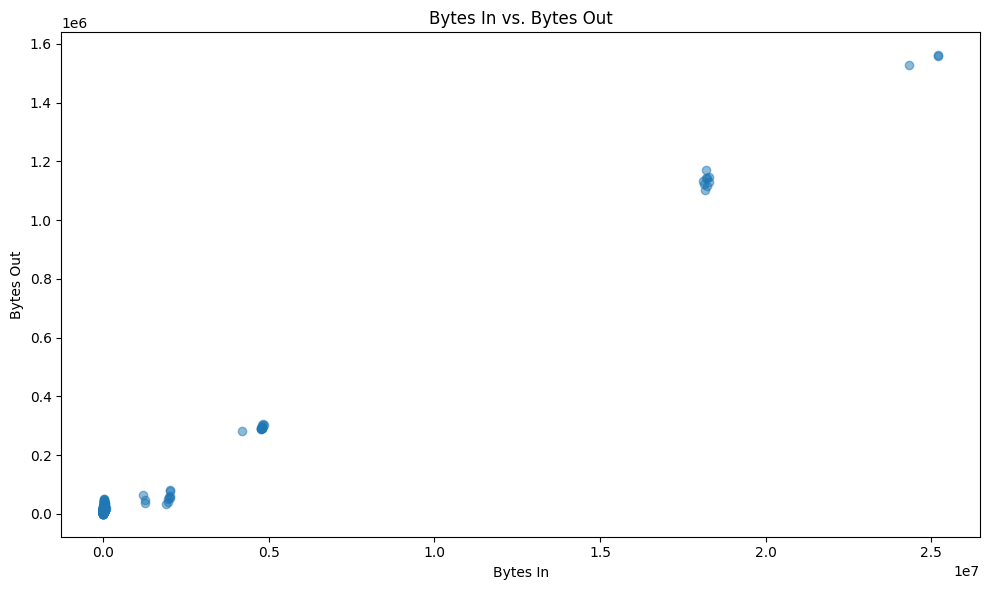

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['bytes_in'], df['bytes_out'], alpha=0.5)
plt.title('Bytes In vs. Bytes Out')
plt.xlabel('Bytes In')
plt.ylabel('Bytes Out')
plt.tight_layout()
plt.show()

## 2. Source Countries

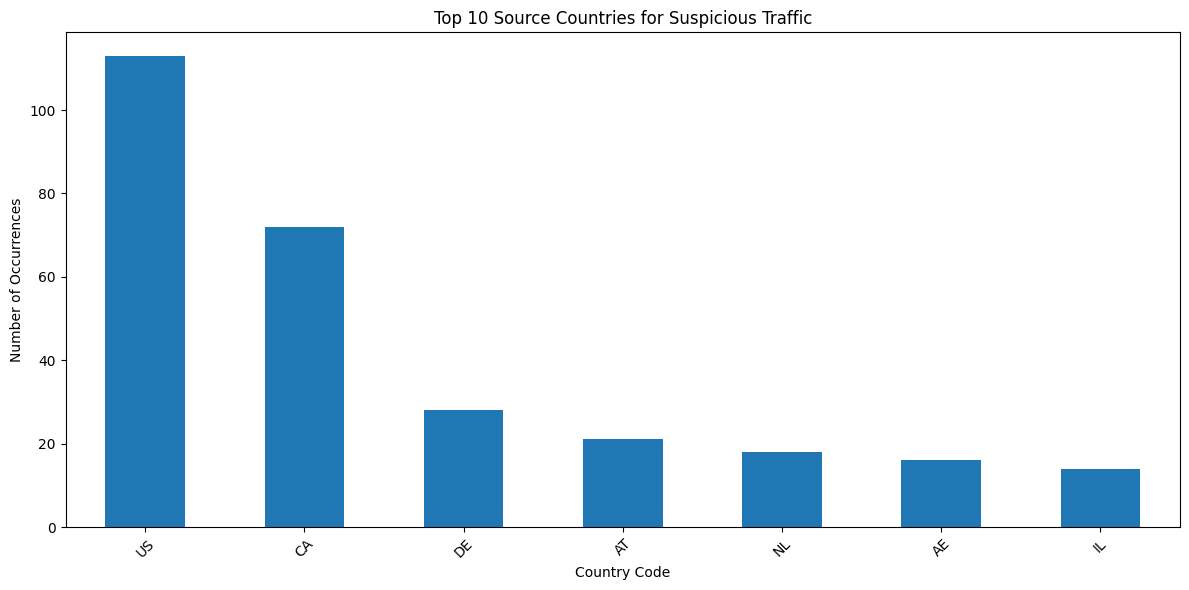

src_ip_country_code
US    40.070922
CA    25.531915
DE     9.929078
AT     7.446809
NL     6.382979
AE     5.673759
IL     4.964539
Name: count, dtype: float64


In [9]:
country_counts = df['src_ip_country_code'].value_counts()

plt.figure(figsize=(12, 6))
country_counts.head(10).plot(kind='bar')
plt.title('Top 10 Source Countries for Suspicious Traffic')
plt.xlabel('Country Code')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(country_counts.head(10) / len(df) * 100) # to print %


In [10]:
country_counts = df['src_ip_country_code'].value_counts().reset_index()
country_counts.columns = ['country_code', 'count']

unique_country_codes = country_counts['country_code'].unique()
print(unique_country_codes)

['US' 'CA' 'DE' 'AT' 'NL' 'AE' 'IL']


In [11]:
country_code_mapping = {
    'US': 'USA',
    'CA': 'CAN',
    'DE': 'DEU',
    'AT': 'AUT',
    'NL': 'NLD',
    'AE': 'ARE',
    'IL': 'ISR'
}

country_counts['country_code_3'] = country_counts['country_code'].map(country_code_mapping)
world = gpd.read_file('ne_110m_admin_0_countries.shp')
world = world.merge(country_counts, how='left', left_on='SOV_A3', right_on='country_code_3')
world['count'] = world['count'].fillna(0)

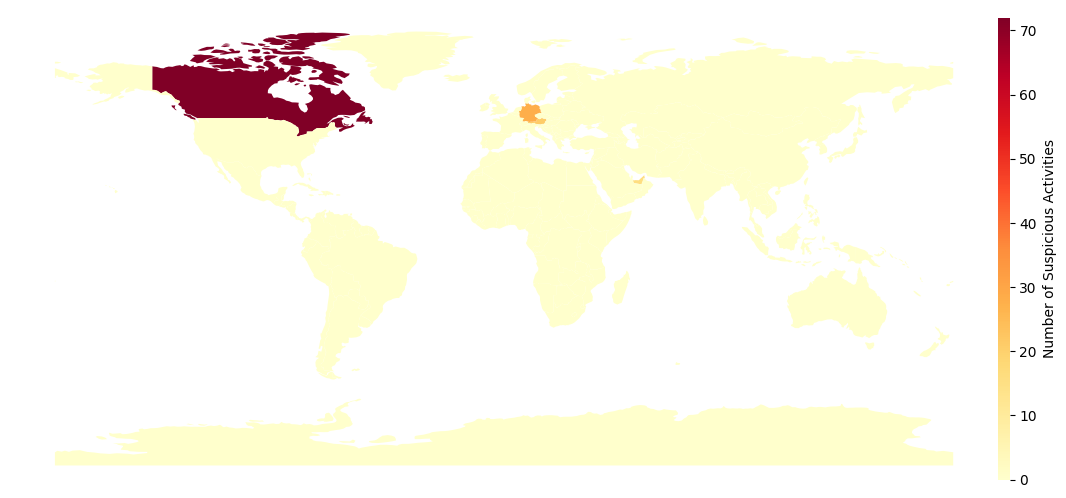

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

world.plot(
    column='count',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Number of Suspicious Activities",
        'orientation': "vertical",
        'shrink': 0.6,
        'aspect': 40,
        'pad': 0,
    },
    cmap='YlOrRd',
    missing_kwds={"color": "lightgrey"}
)

cbar = ax.get_figure().get_axes()[-1]
cbar.set_frame_on(False)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('off')

plt.show()


## 3. Protocols and Destination Ports

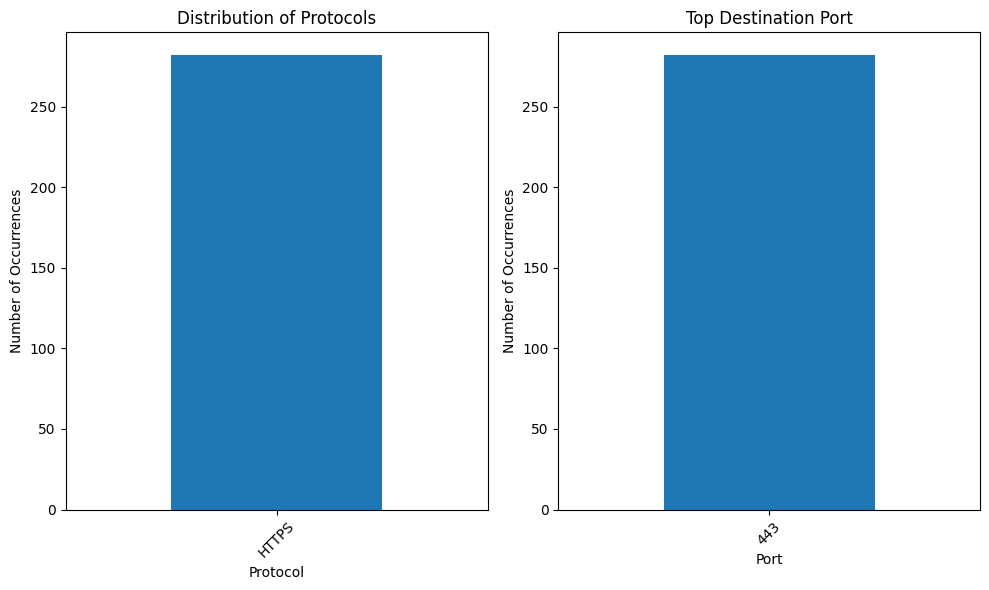

In [13]:
protocol_counts = df['protocol'].value_counts()
port_counts = df['dst_port'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

protocol_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of Protocols')
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Number of Occurrences')
axes[0].tick_params(axis='x', rotation=45)

port_counts.head(10).plot(kind='bar', ax=axes[1])
axes[1].set_title('Top Destination Port')
axes[1].set_xlabel('Port')
axes[1].set_ylabel('Number of Occurrences')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 4. Time of Day

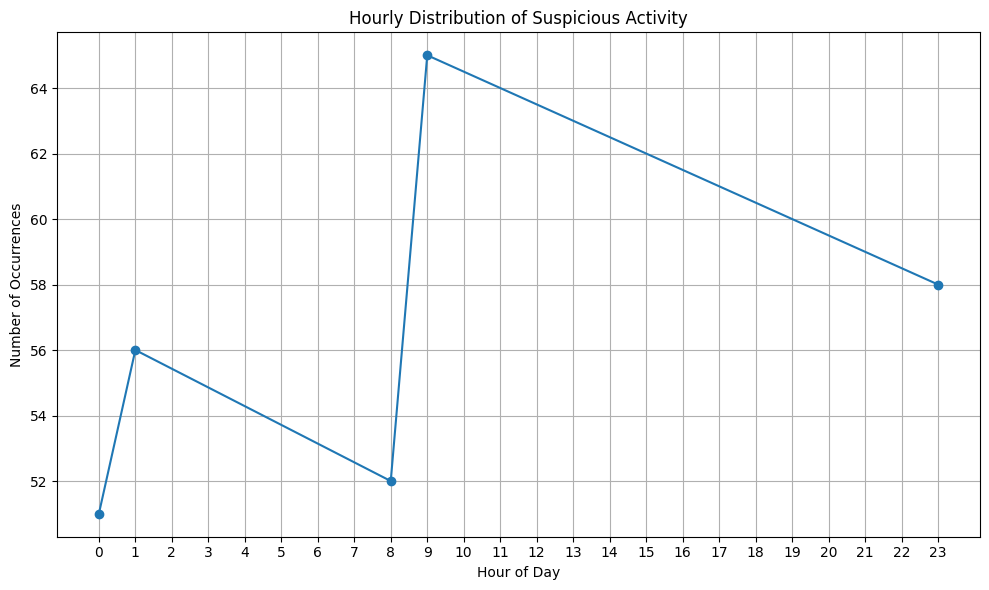

In [14]:
hourly_counts = df.groupby(df['time'].dt.hour).size()

plt.figure(figsize=(10, 6))
hourly_counts.plot(kind='line', marker='o')
plt.title('Hourly Distribution of Suspicious Activity')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Occurrences')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

## Observations:


* **Traffic Volume Pattern**
Most suspicious activities show either very small network traffic (scanning?) or very large traffic, with few points in between.

* **Geographic Sources**
US and Canada account for the majority of suspicious network traffic.

* **Peak Times**
The riskiest times are 1 AM and mid-morning/start of the business day around 9-10 AM
